### Librerías

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

### Carga de datos

In [30]:
# Carga de datos
DATA_PATH = Path("roca_nivaria_datos.xlsx")

df = pd.read_excel(DATA_PATH)

In [37]:
df.sample(5)

,Date,turno,plato,% KG,% Reducción,% Reducción Total,_Tiene Datos,CO2,Comensales,Desperdicio (kg),Desviación %,KG Base,KG Evitados,KG Evitados Totales,kg/Comensal,KG Reales,Registros Procesados,Cobertura Comensales %,Cobertura Pesaje %
12642,08/04/2026,DESAYUNO,Gofres,0.000015,0.932927,0.932927,1,1.100,605.0,0.44,3.623676,6.56,6.12,6.12,0.000727,0.44,1,1.0,1
8891,23/11/2025,CENA,Carne Fiesta,0.000021,0.827586,0.827586,1,1.500,533.0,0.60,3.361564,3.48,2.88,2.88,0.001126,0.60,1,1.0,1
3876,18/07/2025,ALMUERZO,Cambio del día Buffet Caliente Derecha,0.000040,0.958111,0.958111,1,2.950,281.0,1.18,0.559733,28.17,26.99,26.99,0.004199,1.18,1,1.0,1
11879,11/03/2026,CENA,Fruta entera,0.000072,0.349845,0.349845,1,5.250,483.0,2.10,294.015396,3.23,1.13,1.13,0.004348,2.10,1,1.0,1
4252,25/07/2025,CENA,Lentejas con verduras y curry,0.000039,0.740991,0.740991,1,2.875,669.0,1.15,4.914899,4.44,3.29,3.29,0.001719,1.15,1,1.0,1


### Información general del dataset

In [45]:
df.head()

,Date,turno,plato,% KG,% Reducción,% Reducción Total,_Tiene Datos,CO2,Comensales,Desperdicio (kg),Desviación %,KG Base,KG Evitados,KG Evitados Totales,kg/Comensal,KG Reales,Registros Procesados,Cobertura Comensales %,Cobertura Pesaje %
0,05/05/2025,DESAYUNO,Cereales,0.000024,0.774194,0.774194,1,1.75,616.0,0.70,16.907819,3.10,2.40,2.40,0.001136,0.70,1,1.0,1
1,05/05/2025,DESAYUNO,Creps,0.000038,0.827316,0.827316,1,2.75,616.0,1.10,11.620748,6.37,5.27,5.27,0.001786,1.10,1,1.0,1
2,05/05/2025,DESAYUNO,Croissant,0.000003,0.750000,0.750000,1,0.25,616.0,0.10,5.692821,0.40,0.30,0.30,0.000162,0.10,1,1.0,1
3,05/05/2025,DESAYUNO,Dulces,0.000014,0.871166,0.871166,1,1.05,616.0,0.42,11.630295,3.26,2.84,2.84,0.000682,0.42,1,1.0,1
4,05/05/2025,DESAYUNO,Embutidos,0.000024,0.916468,0.916468,1,1.75,616.0,0.70,1.967767,8.38,7.68,7.68,0.001136,0.70,1,1.0,1


In [32]:
df.tail()

,Date,turno,plato,% KG,% Reducción,% Reducción Total,_Tiene Datos,CO2,Comensales,Desperdicio (kg),Desviación %,KG Base,KG Evitados,KG Evitados Totales,kg/Comensal,KG Reales,Registros Procesados,Cobertura Comensales %,Cobertura Pesaje %
15366,01/07/2026,CENA,Pizza,0.000017,0.948294,0.948294,1,1.25,517.0,0.50,2.618354,9.67,9.17,9.17,0.000967,0.50,1,1.0,1
15367,01/07/2026,CENA,Salchichas,0.000042,0.941454,0.941454,1,3.10,517.0,1.24,1.810590,21.18,19.94,19.94,0.002398,1.24,1,1.0,1
15368,01/07/2026,CENA,Salsa a la Menta,0.000009,0.711111,0.711111,1,0.65,517.0,0.26,8.469846,0.90,0.64,0.64,0.000503,0.26,1,1.0,1
15369,01/07/2026,CENA,Sopas y Cremas,0.000081,0.987674,0.987674,1,5.95,517.0,2.38,-0.133227,193.08,190.70,190.70,0.004603,2.38,1,1.0,1
15370,01/07/2026,CENA,Verduras,0.000045,0.959976,0.959976,1,3.30,517.0,1.32,1.529567,32.98,31.66,31.66,0.002553,1.32,1,1.0,1


In [38]:
df.shape

(15371, 19)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15371 entries, 0 to 15370
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    15371 non-null  object 
 1   turno                   15371 non-null  object 
 2   plato                   15371 non-null  object 
 3   % KG                    15371 non-null  float64
 4   % Reducción             15293 non-null  float64
 5   % Reducción Total       15293 non-null  float64
 6   _Tiene Datos            15371 non-null  int64  
 7   CO2                     15371 non-null  float64
 8   Comensales              15021 non-null  float64
 9   Desperdicio (kg)        15371 non-null  float64
 10  Desviación %            15021 non-null  float64
 11  KG Base                 15293 non-null  float64
 12  KG Evitados             15293 non-null  float64
 13  KG Evitados Totales     15293 non-null  float64
 14  kg/Comensal             15021 non-null

In [40]:
df.describe()

,% KG,% Reducción,% Reducción Total,_Tiene Datos,CO2,Comensales,Desperdicio (kg),Desviación %,KG Base,KG Evitados,KG Evitados Totales,kg/Comensal,KG Reales,Registros Procesados,Cobertura Comensales %,Cobertura Pesaje %
count,1.537100e+04,15293.000000,15293.000000,15371.0,15371.000000,15021.000000,15371.000000,15021.000000,15293.000000,15293.000000,15293.000000,15021.000000,15371.000000,15371.000000,15021.0,15371.0
mean,6.505758e-05,0.770107,0.770107,1.0,4.756361,497.311764,1.902544,8.614470,24.216608,22.384423,22.384423,0.004738,1.902544,1.256587,1.0,1.0
std,9.149843e-05,0.263409,0.263409,0.0,6.689452,291.681389,2.675781,22.945340,42.321629,40.958654,40.958654,0.008445,2.675781,0.598959,0.0,0.0
min,6.839007e-07,0.000000,0.000000,1.0,0.050000,110.000000,0.020000,-0.978964,0.100000,0.000000,0.000000,0.000017,0.020000,1.000000,1.0,1.0
25%,2.256872e-05,0.694444,0.694444,1.0,1.650000,303.000000,0.660000,0.799499,3.420000,2.420000,2.420000,0.001370,0.660000,1.000000,1.0,1.0
50%,4.035014e-05,0.878049,0.878049,1.0,2.950000,549.000000,1.180000,3.066423,9.670000,8.350000,8.350000,0.002533,1.180000,1.000000,1.0,1.0
75%,7.112568e-05,0.950617,0.950617,1.0,5.200000,618.000000,2.080000,8.954097,21.180000,20.270000,20.270000,0.005018,2.080000,1.000000,1.0,1.0
max,3.535767e-03,0.999546,0.999546,1.0,258.500000,6015.000000,103.400000,484.847870,203.570000,202.650000,202.650000,0.309333,103.400000,4.000000,1.0,1.0


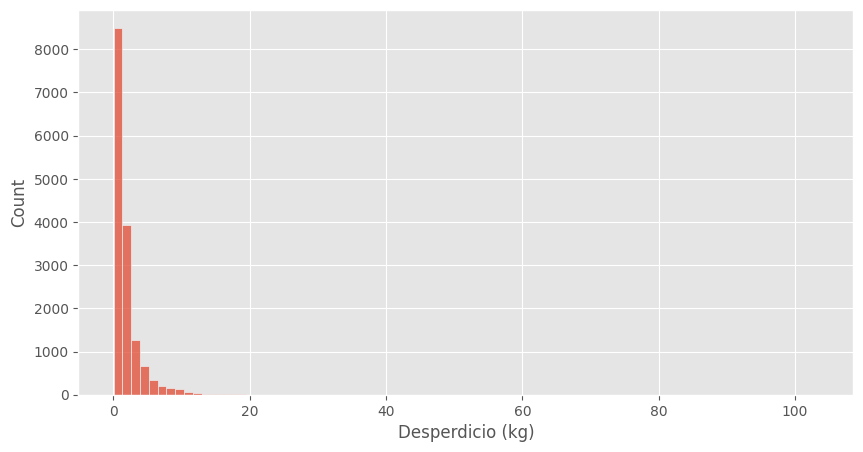

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(df["Desperdicio (kg)"], bins=80)

plt.show()

<Axes: xlabel='Desperdicio (kg)'>

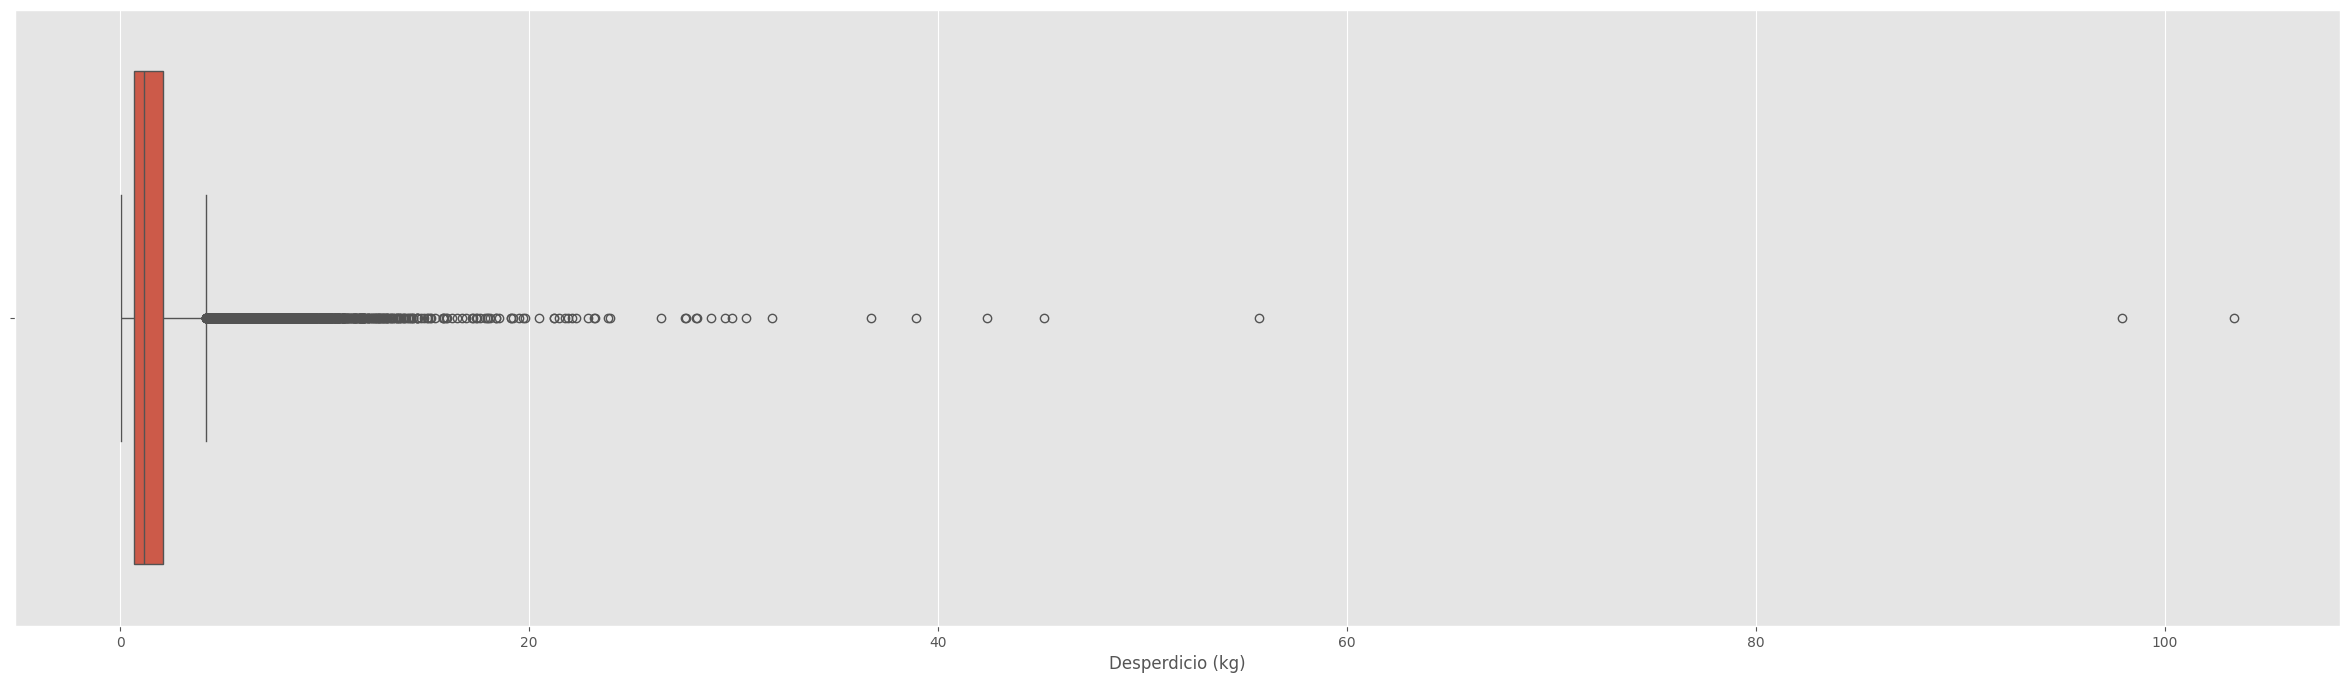

In [42]:
plt.figure(figsize=(30,8))

sns.boxplot(x=df["Desperdicio (kg)"])

<Axes: xlabel='Date'>

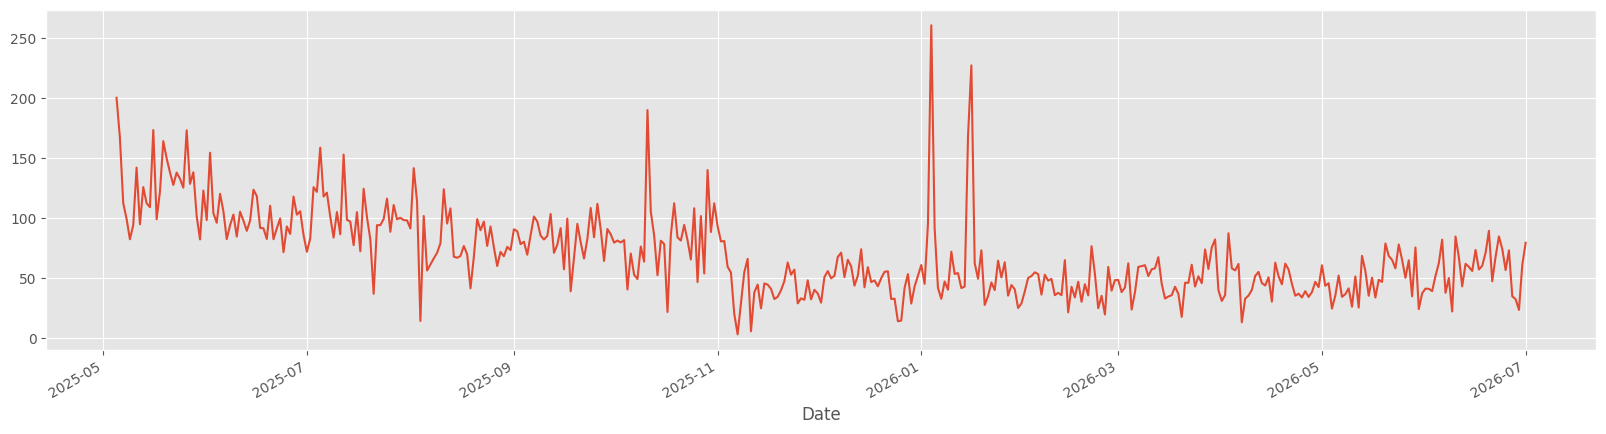

In [55]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date")

daily = (
    df.groupby("Date")["Desperdicio (kg)"]
      .sum()
      .sort_index()
)

daily.plot(figsize=(20,5))

<Axes: >

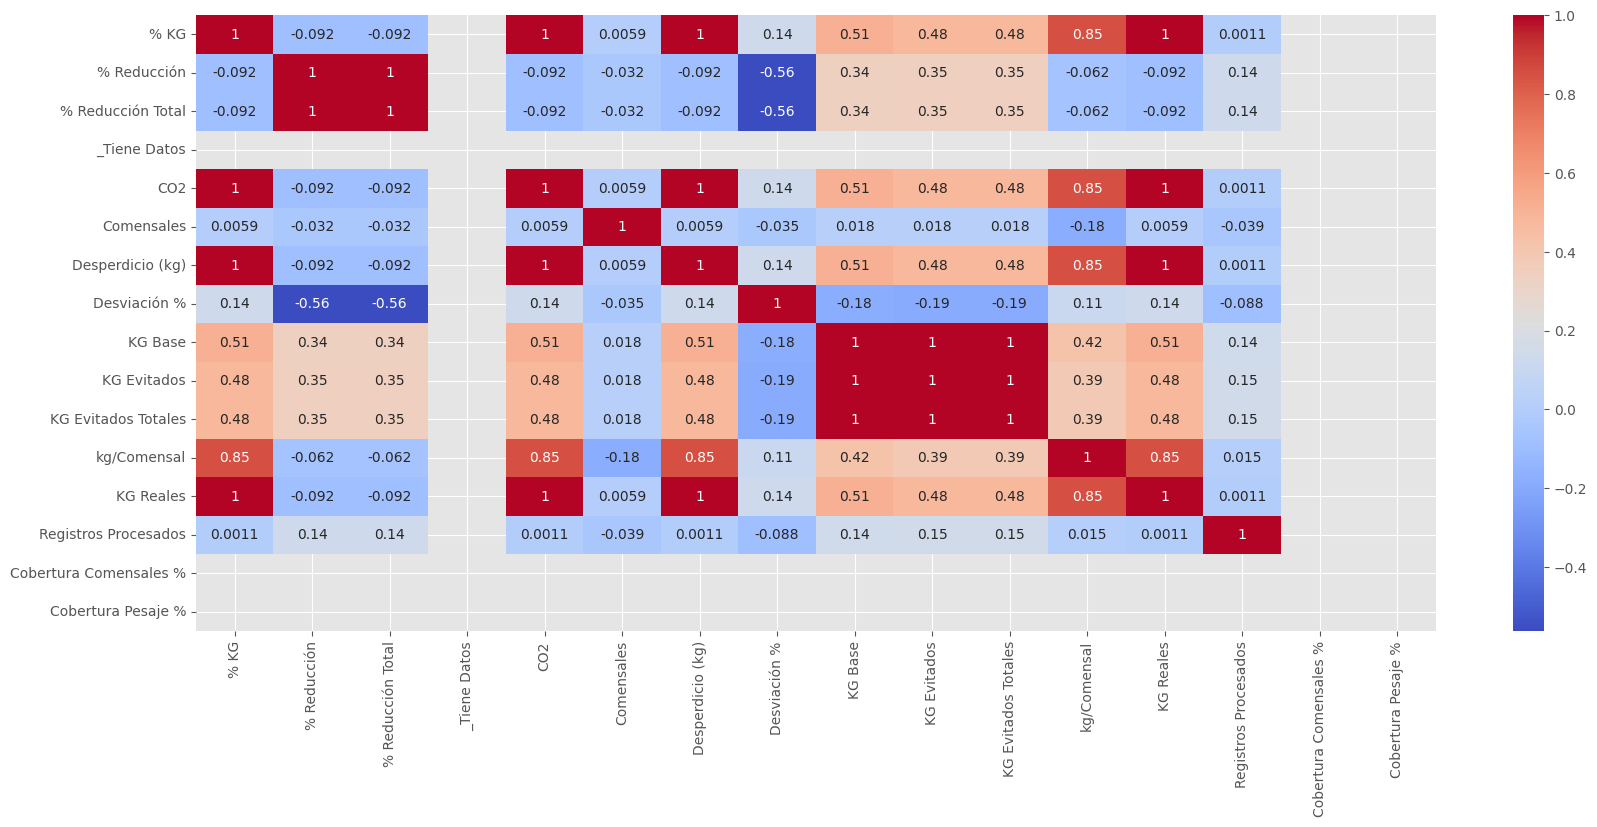

In [44]:
numeric = df.select_dtypes(include=np.number)

numeric.describe().T

corr = numeric.corr()

plt.figure(figsize=(20,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

In [ ]:
df.nlargest(50, "Desperdicio (kg)")[["Date","turno","plato","Comensales","Desperdicio (kg)"]]

,Date,turno,plato,Comensales,Desperdicio (kg)
10003,2026-01-04,CENA,Plato Cambio del Día Buffet Frío,476.0,103.40
9996,2026-01-04,CENA,Helados,476.0,97.90
741,2025-05-19,ALMUERZO,Comedor del personal,180.0,55.68
8247,2025-10-29,ALMUERZO,Comedor del personal,234.0,45.18
1175,2025-05-26,ALMUERZO,Comedor del personal,251.0,42.38
596,2025-05-16,ALMUERZO,Comedor del personal,193.0,38.93
10315,2026-01-15,CENA,Risotto Cremoso con Vegetales (vegano),535.0,36.72
10346,2026-01-16,CENA,Pechuga de Pollo Agridulce,504.0,31.86
10350,2026-01-16,CENA,Salsa Agridulce,504.0,30.60
3562,2025-07-12,ALMUERZO,Comedor del personal,351.0,29.94
